# STAT 486 Project — Unsupervised Learning
## What Are the Operational Signatures of Flight Delays?

**Research question:** When a flight is delayed, does it fall into a recognisable *operational* pattern — or is every delay unique?

**Approach:** Among flights that experienced a delay in 2024, we use K-Means clustering to group them by how the delay unfolded operationally: how large was the departure delay, did the flight recover time in the air, was there unusual ground-hold time, what time of day did it depart, and how long was the route? Crucially, **we do not use delay-cause codes as clustering features** — those are held back and used only as a post-hoc validation check. If operationally similar flights also share similar root causes, that is a genuine finding, not a tautology built into the model.

---
**Dataset:** U.S. domestic flights, 2024 sample · 10,000 flight-level records · 15 carriers · 284 origin airports  
**Unit of analysis:** One row = one individual flight  
**Analysis subset:** ~2,100 flights with a logged delay cause (21% of all flights)

In [9]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

ROOT = Path.cwd()
if not (ROOT / 'flight_data_2024_sample.csv').exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / 'flight_data_2024_sample.csv'
FIG_DIR   = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 486

CARRIER_NAMES = {
    'WN':'Southwest','DL':'Delta','AA':'American','OO':'SkyWest',
    'UA':'United','YX':'Republic','MQ':'Envoy','NK':'Spirit',
    'B6':'JetBlue','OH':'PSA','AS':'Alaska','F9':'Frontier',
    '9E':'Endeavor','G4':'Allegiant','HA':'Hawaiian',
}

---
## 1. Preparing the Data

We load the raw flight records and isolate the flights that actually experienced a delay with a logged cause. Flights that departed and arrived on time, or that were cancelled, are excluded — they have no operational delay profile to analyse.

We also compute the **cause fraction** for each delayed flight (what share of total delay came from each root cause). These fractions are **not used as clustering features** — they are held back for a validation check in Section 6.

In [10]:
df = pd.read_csv(DATA_PATH)

CAUSE_COLS = ['carrier_delay','weather_delay','nas_delay',
              'security_delay','late_aircraft_delay']

df['total_cause'] = df[CAUSE_COLS].sum(axis=1)

# Keep only flights where at least one delay cause is logged
delayed = df[df['total_cause'] > 0].copy().reset_index(drop=True)

print('=' * 52)
print('DATASET SUMMARY')
print('=' * 52)
print(f'Total flights in dataset       : {len(df):>7,}')
print(f'Flights with a logged delay    : {len(delayed):>7,}  ({len(delayed)/len(df):.1%})')
print(f'Carriers represented           : {delayed["op_unique_carrier"].nunique():>7}')
print(f'Origin airports represented    : {delayed["origin"].nunique():>7}')
print()
print('Dominant delay cause per flight:')
for col in CAUSE_COLS:
    delayed[f'pct_{col}'] = delayed[col] / delayed['total_cause']
dom = delayed[[f'pct_{c}' for c in CAUSE_COLS]].idxmax(axis=1).value_counts()
labels = {'pct_carrier_delay':'Carrier fault',
          'pct_weather_delay':'Weather',
          'pct_nas_delay':'Air traffic / NAS',
          'pct_security_delay':'Security',
          'pct_late_aircraft_delay':'Late incoming aircraft'}
for k,v in dom.items():
    print(f'  {labels[k]:<28}: {v:>5,}  ({v/len(delayed):.1%})')

DATASET SUMMARY
Total flights in dataset       :  10,000
Flights with a logged delay    :   2,119  (21.2%)
Carriers represented           :      15
Origin airports represented    :     190

Dominant delay cause per flight:
  Late incoming aircraft      :   839  (39.6%)
  Carrier fault               :   618  (29.2%)
  Air traffic / NAS           :   563  (26.6%)
  Weather                     :    95  (4.5%)
  Security                    :     4  (0.2%)


---
## 2. Feature Engineering

We describe each delayed flight using **operational observables** — things measurable from the flight's actual trajectory, without knowing *why* it was delayed. Delay-cause codes are computed in Section 1 but deliberately excluded from the feature set; they serve as a validation check in Section 6.

| Feature | What it measures | Why it matters |
|---|---|---|
| `dep_delay` | Total departure delay (minutes) | Magnitude of delay at the gate |
| `recovery_delta` | `arr_delay − dep_delay` | Did the crew recover time in the air? Negative = recovered; positive = worsened |
| `taxi_out` | Minutes from pushback to wheels-off | Elevated values signal ground congestion or ATC ground holds |
| `distance` | Route length (miles) | Short-haul routes have less airborne buffer to recover; long-haul have more |
| `dep_hour_sin`, `dep_hour_cos` | Cyclical encoding of scheduled departure hour | Captures time-of-day effects (morning "fresh start" vs. evening accumulated cascade); cyclical so 11 PM and midnight are treated as adjacent |

**Why `recovery_delta` matters:** A flight that departs 40 minutes late but arrives only 15 minutes late (`recovery_delta = −25`) is operationally very different from one that departs 40 minutes late and arrives 55 minutes late (`recovery_delta = +15`). These two flights would be clustered separately even if their departure delays were identical.

**What is deliberately excluded:** `carrier_delay`, `weather_delay`, `nas_delay`, `late_aircraft_delay` and all `pct_*` fractions derived from them. Using cause codes as clustering features and then naming clusters after causes is circular — the model would be guaranteed to find exactly what it was told to look for. By excluding them here and checking them afterward, we can ask a non-trivial question: *do flights that look operationally similar also tend to share the same root cause?*

In [11]:
# ── Operational features — no delay-cause codes ───────────────────────────────

# Recovery delta: how much did the flight gain or lose vs its departure delay?
# Negative = crew recovered time in air; positive = flight worsened in transit
delayed['recovery_delta'] = delayed['arr_delay'] - delayed['dep_delay']

# Scheduled departure hour with cyclical encoding (so 23:00 and 00:30 are "close")
delayed['dep_hour'] = (delayed['crs_dep_time'] // 100) + (delayed['crs_dep_time'] % 100) / 60.0
delayed['dep_hour_sin'] = np.sin(2 * np.pi * delayed['dep_hour'] / 24)
delayed['dep_hour_cos'] = np.cos(2 * np.pi * delayed['dep_hour'] / 24)

CLUSTER_FEATURES = [
    'dep_delay',        # departure delay magnitude
    'recovery_delta',   # arr_delay − dep_delay (negative = recovered in air)
    'taxi_out',         # ground-hold signal
    'distance',         # route length
    'dep_hour_sin',     # time-of-day, cyclical part 1
    'dep_hour_cos',     # time-of-day, cyclical part 2
]

X = delayed[CLUSTER_FEATURES].dropna()
delayed = delayed.loc[X.index].copy()   # keep only rows with complete features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

print('Feature matrix shape:', X_scaled.shape)
print()
print('Feature summary (raw values, delayed flights only):')
for feat in ['dep_delay', 'recovery_delta', 'taxi_out', 'distance', 'dep_hour']:
    col = delayed[feat]
    print(f'  {feat:<20}: mean={col.mean():>7.1f}  std={col.std():>6.1f}  '
          f'p10={col.quantile(0.10):>7.1f}  p90={col.quantile(0.90):>7.1f}')

Feature matrix shape: (2119, 6)

Feature summary (raw values, delayed flights only):
  dep_delay           : mean=   67.0  std=  96.6  p10=   -1.0  p90=  147.0
  recovery_delta      : mean=    4.4  std=  21.6  p10=  -17.0  p90=   31.0
  taxi_out            : mean=   22.6  std=  15.8  p10=   11.0  p90=   41.0
  distance            : mean=  855.8  std= 582.4  p10=  236.0  p90= 1660.0
  dep_hour            : mean=   14.8  std=   4.7  p10=    7.8  p90=   20.7


---
## 3. Choosing the Number of Clusters

We test K from 2 to 8 using two metrics:

- **Inertia** (elbow): how compact the clusters are internally. Look for the point where adding another cluster stops helping much.
- **Silhouette score**: how well-separated the clusters are from each other. Higher is better; the peak marks the best k.

We expect k = 4 to be near-optimal, corresponding to the four non-trivial delay causes.

Best k by silhouette score: 5

  k   inertia   silhouette
  2   10273.7   0.2300
  3    8449.9   0.2453
  4    7557.9   0.2469
  5    6621.2   0.2576 <-- best
  6    5966.0   0.2206
  7    5531.7   0.2221
  8    5163.5   0.2205


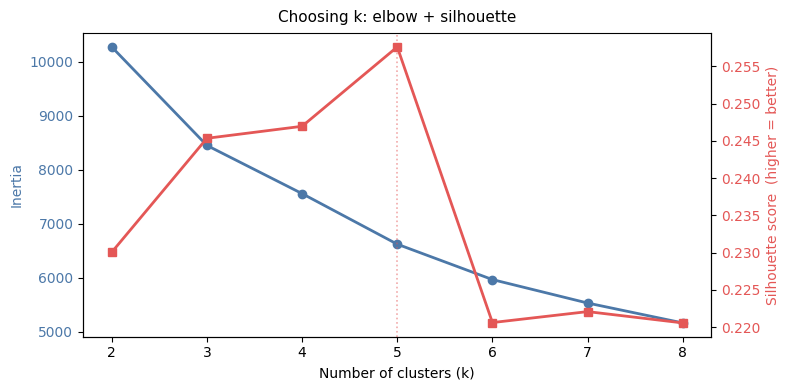

In [12]:
k_values    = list(range(2, 9))
inertias    = []
sil_scores  = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20, algorithm='lloyd')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = k_values[int(np.argmax(sil_scores))]
print(f'Best k by silhouette score: {best_k}')
print()
print(f'  k   inertia   silhouette')
for k, ine, sil in zip(k_values, inertias, sil_scores):
    marker = ' <-- best' if k == best_k else ''
    print(f'  {k}   {ine:7.1f}   {sil:.4f}{marker}')

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(k_values, inertias, marker='o', color='#4C78A8', linewidth=2)
ax1.set_xlabel('Number of clusters (k)', fontsize=10)
ax1.set_ylabel('Inertia', color='#4C78A8', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#4C78A8')

ax2 = ax1.twinx()
ax2.plot(k_values, sil_scores, marker='s', color='#E45756', linewidth=2)
ax2.set_ylabel('Silhouette score  (higher = better)', color='#E45756', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#E45756')
ax2.axvline(best_k, color='#E45756', linestyle=':', linewidth=1.2, alpha=0.5)

ax1.set_title('Choosing k: elbow + silhouette', fontsize=11, pad=8)
ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'delay_cluster_model_selection.png', dpi=150)
plt.show()

In [13]:
K = best_k
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20, algorithm='lloyd')
delayed['cluster'] = kmeans.fit_predict(X_scaled)

# ── Name each cluster from its operational centroid ───────────────────────────
centroids_scaled = kmeans.cluster_centers_
centroids_raw = pd.DataFrame(
    scaler.inverse_transform(centroids_scaled),
    columns=CLUSTER_FEATURES
)

def decode_hour(sin_val, cos_val):
    """Recover hour of day (0–24) from cyclical sin/cos encoding."""
    h = np.degrees(np.arctan2(sin_val, cos_val)) / 360 * 24
    return h % 24

# Z-score each centroid feature relative to the overall delayed-flight distribution
overall = {f: (delayed[f].mean(), delayed[f].std())
           for f in ['dep_delay', 'recovery_delta', 'taxi_out', 'distance']}

def z(val, feat):
    mu, sd = overall[feat]
    return (val - mu) / sd if sd > 0 else 0

def label_cluster(row):
    h      = decode_hour(row['dep_hour_sin'], row['dep_hour_cos'])
    # Finer time-of-day buckets so 6–7 PM reads as "Evening"
    time   = ('Early Morning' if h < 7  else
              'Morning'       if h < 12 else
              'Midday'        if h < 15 else
              'Afternoon'     if h < 18 else
              'Evening')
    tz  = z(row['taxi_out'],       'taxi_out')
    dz  = z(row['dep_delay'],      'dep_delay')
    rz  = z(row['recovery_delta'], 'recovery_delta')
    dist_z = z(row['distance'],    'distance')

    # Most distinctive operational feature drives the label
    if tz >= 0.75:
        return f'{time} Ground-Hold'
    elif dz >= 1.5:
        return f'{time} Extreme Delay'
    elif rz >= 0.75 and tz >= 0.25:
        return f'{time} Worsening'
    elif rz <= -0.75:
        return f'{time} Recoverable'
    elif dist_z >= 0.75:
        return f'{time} Long-Haul'
    else:
        return f'{time} Moderate Delay'

cluster_name_map = {cid: label_cluster(centroids_raw.iloc[cid]) for cid in range(K)}

# Deduplicate names if two clusters earn the same label
from collections import Counter
counts = Counter(cluster_name_map.values())
dup_counter = {}
for cid, name in cluster_name_map.items():
    if counts[name] > 1:
        dup_counter[name] = dup_counter.get(name, 0) + 1
        cluster_name_map[cid] = f'{name} ({dup_counter[name]})'

delayed['cluster_name'] = delayed['cluster'].map(cluster_name_map)

print('Cluster assignments:')
for cid in sorted(cluster_name_map):
    n = (delayed['cluster'] == cid).sum()
    h = decode_hour(centroids_raw.loc[cid, 'dep_hour_sin'], centroids_raw.loc[cid, 'dep_hour_cos'])
    print(f'  Cluster {cid}  ({n:>4} flights)  →  {cluster_name_map[cid]}')
    print(f'    dep_delay={centroids_raw.loc[cid,"dep_delay"]:.1f} min  '
          f'recovery_delta={centroids_raw.loc[cid,"recovery_delta"]:.1f} min  '
          f'taxi_out={centroids_raw.loc[cid,"taxi_out"]:.1f} min  '
          f'distance={centroids_raw.loc[cid,"distance"]:.0f} mi  '
          f'dep_hour={h:.1f}h')

Cluster assignments:
  Cluster 0  ( 256 flights)  →  Afternoon Long-Haul
    dep_delay=54.8 min  recovery_delta=0.9 min  taxi_out=21.4 min  distance=2022 mi  dep_hour=15.4h
  Cluster 1  ( 821 flights)  →  Evening Moderate Delay
    dep_delay=63.9 min  recovery_delta=-2.2 min  taxi_out=17.6 min  distance=671 mi  dep_hour=18.7h
  Cluster 2  ( 756 flights)  →  Morning Moderate Delay
    dep_delay=51.6 min  recovery_delta=2.5 min  taxi_out=19.2 min  distance=695 mi  dep_hour=10.8h
  Cluster 3  ( 216 flights)  →  Afternoon Ground-Hold
    dep_delay=29.0 min  recovery_delta=44.9 min  taxi_out=57.3 min  distance=763 mi  dep_hour=15.1h
  Cluster 4  (  70 flights)  →  Midday Extreme Delay
    dep_delay=431.3 min  recovery_delta=-8.5 min  taxi_out=16.5 min  distance=801 mi  dep_hour=13.5h


---
## 4. Cluster Profiles: What Does Each Operational Group Look Like?

The heatmap below shows each cluster's average feature values standardised against the overall mean. **Red** means above average for that feature; **blue** means below average. Raw (unstandardised) averages are annotated inside each cell so you can read the actual scale.

All features shown here are operational observables — departure delay, in-flight recovery, taxi time, route distance, and departure hour. **Delay cause codes are absent; they appear in Section 6 as a post-hoc validation check.**

> **Note on the extreme-delay cluster:** One cluster is characterised by a very high mean departure delay (≈ 430 min) and contains only ~70 flights. It almost certainly represents catastrophic disruption events — weather ground stops, ground holds, system-wide failures — rather than a recurrent operational pattern. K-Means isolates it because minimising inertia strongly incentivises pulling extreme points into their own cluster. It is retained in all analyses for completeness, but labelled here as an outlier bin rather than a behavioural archetype. Section 10 checks whether removing these flights materially changes the structure of the remaining clusters.

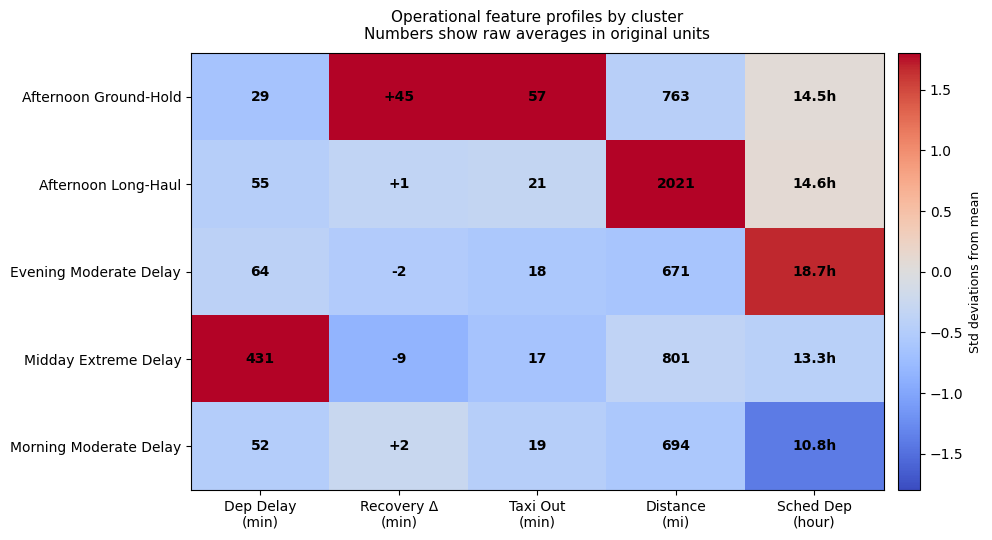

In [14]:
name_order = sorted(delayed['cluster_name'].unique())

# Build display profiles with human-readable units
# dep_hour already in delayed from feature engineering; use it directly
profiles = delayed.groupby('cluster_name')[CLUSTER_FEATURES + ['dep_hour']].mean().loc[name_order]

DISPLAY_FEATURES = ['dep_delay', 'recovery_delta', 'taxi_out', 'distance', 'dep_hour']
DISPLAY_LABELS   = ['Dep Delay\n(min)', 'Recovery Δ\n(min)', 'Taxi Out\n(min)',
                    'Distance\n(mi)', 'Sched Dep\n(hour)']
CELL_FMTS        = ['{:.0f}', '{:+.0f}', '{:.0f}', '{:.0f}', '{:.1f}h']

profiles_display = profiles[DISPLAY_FEATURES]
z_profiles = (profiles_display - profiles_display.mean()) / profiles_display.std(ddof=0)

fig, ax = plt.subplots(figsize=(10, max(3, len(profiles_display) * 0.9 + 1)))
im = ax.imshow(z_profiles.values, aspect='auto', cmap='coolwarm', vmin=-1.8, vmax=1.8)

ax.set_xticks(range(len(DISPLAY_FEATURES)))
ax.set_xticklabels(DISPLAY_LABELS, fontsize=10)
ax.set_yticks(range(len(profiles_display)))
ax.set_yticklabels(profiles_display.index, fontsize=10)

for i, row_name in enumerate(profiles_display.index):
    for j, (feat, fmt) in enumerate(zip(DISPLAY_FEATURES, CELL_FMTS)):
        val = profiles_display.loc[row_name, feat]
        ax.text(j, i, fmt.format(val), ha='center', va='center',
                fontsize=10, color='black', fontweight='bold')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Std deviations from mean', fontsize=9)
ax.set_title('Operational feature profiles by cluster\nNumbers show raw averages in original units',
             fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'delay_cluster_profiles.png', dpi=150)
plt.show()

---
## 5. Are the Clusters Well-Separated?

Since we clustered in a 6-dimensional space, we use PCA to project everything onto two dimensions for visualisation. Unlike the previous approach — where clustering on cause fractions (which sum to 1) forced all points onto a 3-dimensional simplex and produced the triangular fan shape — operational features have no such geometric constraint. Genuinely distinct blobs are now possible. Well-separated blobs here mean the clusters represent real operational groupings, not arbitrary divisions of a continuous cloud. The degree of overlap visible in the PCA scatter is consistent with the silhouette score of 0.26 from Section 3, which sits at the bottom of the 'weak structure' range. Flight delays exist on a continuum rather than in discrete, well-separated buckets, so heavy blob overlap is expected. The clusters should be read as regions of elevated density — loose operational tendencies — rather than tight, disjoint archetypes.

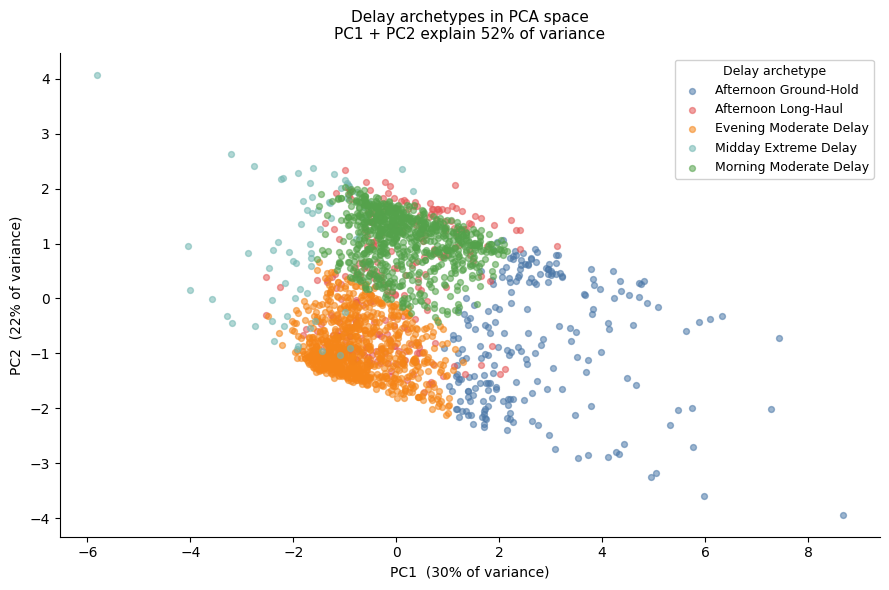

In [15]:
pca    = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
delayed['pc1'] = coords[:, 0]
delayed['pc2'] = coords[:, 1]
var_exp = pca.explained_variance_ratio_

PALETTE = ['#4C78A8','#E45756','#F58518','#72B7B2','#54A24B','#B279A2','#FF9DA6','#9D755D']
name_order = sorted(delayed['cluster_name'].unique())
color_map  = {name: PALETTE[i] for i, name in enumerate(name_order)}

fig, ax = plt.subplots(figsize=(9, 6))
for name in name_order:
    mask = delayed['cluster_name'] == name
    ax.scatter(delayed.loc[mask,'pc1'], delayed.loc[mask,'pc2'],
               c=color_map[name], s=18, alpha=0.55, label=name)

ax.set_title(f'Delay archetypes in PCA space\nPC1 + PC2 explain {var_exp.sum():.0%} of variance',
             fontsize=11, pad=10)
ax.set_xlabel(f'PC1  ({var_exp[0]:.0%} of variance)', fontsize=10)
ax.set_ylabel(f'PC2  ({var_exp[1]:.0%} of variance)', fontsize=10)
ax.legend(title='Delay archetype', fontsize=9, title_fontsize=9,
          loc='upper right', framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'delay_cluster_pca.png', dpi=150)
plt.show()

---
## 6. Validation: Do Operational Clusters Differ in Delay Cause?

The clustering above used **only operational observables** — no cause codes. Here we ask the key validation question: when we break delayed flights into these operational groups, do the groups differ systematically in *why* the delay happened?

If yes, that is a genuine finding: operational patterns observable from a flight's trajectory predict root cause. If the cause mix were uniform across clusters, the operational signatures would tell us nothing about underlying mechanisms. The heatmap below uses the `pct_*` columns that were held out of the clustering step entirely.

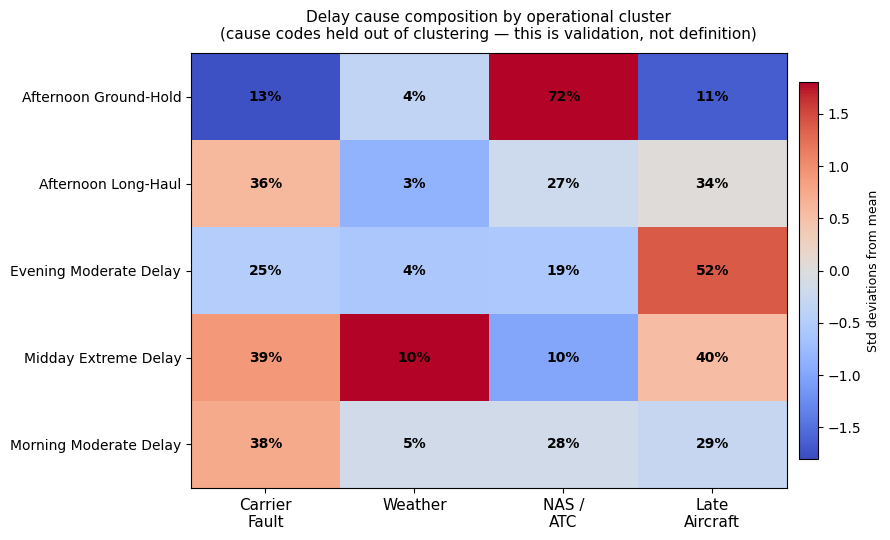


Cause composition by cluster:
                       pct_carrier_delay pct_weather_delay pct_nas_delay pct_late_aircraft_delay
cluster_name                                                                                    
Afternoon Ground-Hold              12.8%              4.3%         72.0%                   10.8%
Afternoon Long-Haul                36.3%              3.0%         26.7%                   33.6%
Evening Moderate Delay             25.5%              3.7%         19.0%                   51.9%
Midday Extreme Delay               39.4%             10.4%          9.9%                   40.3%
Morning Moderate Delay             37.7%              4.8%         27.8%                   29.3%


In [16]:
CAUSE_PCT_COLS = [
    'pct_carrier_delay',
    'pct_weather_delay',
    'pct_nas_delay',
    'pct_late_aircraft_delay',
]
CAUSE_LABELS = ['Carrier\nFault', 'Weather', 'NAS /\nATC', 'Late\nAircraft']

cause_profiles = delayed.groupby('cluster_name')[CAUSE_PCT_COLS].mean().loc[name_order]
z_cause = (cause_profiles - cause_profiles.mean()) / cause_profiles.std(ddof=0)

fig, ax = plt.subplots(figsize=(9, max(3, len(cause_profiles) * 0.9 + 1)))
im = ax.imshow(z_cause.values, aspect='auto', cmap='coolwarm', vmin=-1.8, vmax=1.8)

ax.set_xticks(range(len(CAUSE_PCT_COLS)))
ax.set_xticklabels(CAUSE_LABELS, fontsize=11)
ax.set_yticks(range(len(cause_profiles)))
ax.set_yticklabels(cause_profiles.index, fontsize=10)

for i, row_name in enumerate(cause_profiles.index):
    for j, col in enumerate(CAUSE_PCT_COLS):
        val = cause_profiles.loc[row_name, col]
        ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                fontsize=10, color='black', fontweight='bold')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Std deviations from mean', fontsize=9)
ax.set_title('Delay cause composition by operational cluster\n'
             '(cause codes held out of clustering — this is validation, not definition)',
             fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'delay_cluster_cause_validation.png', dpi=150)
plt.show()

print('\nCause composition by cluster:')
print(cause_profiles.map('{:.1%}'.format).to_string())

---
## 7. Do the Clusters Differ in Delay Severity?

Clustering by operational signature tells us *how* a delay unfolded. Now we check whether the operational patterns also differ in *how bad* the total arrival delay was. `arr_delay` entered the clustering only indirectly (through `recovery_delta = arr_delay − dep_delay`), so total severity is not mechanically determined by cluster membership.

Delay severity by archetype:
             Archetype  Flights  Median delay  Mean delay  90th pct delay  % >= 60 min
  Midday Extreme Delay       70         359.0  422.757143           662.2     1.000000
 Afternoon Ground-Hold      216          53.0   73.930556           159.5     0.449074
Evening Moderate Delay      821          45.0   61.711328           133.0     0.372716
   Afternoon Long-Haul      256          35.0   55.531250           126.0     0.285156
Morning Moderate Delay      756          36.0   54.071429           117.0     0.293651


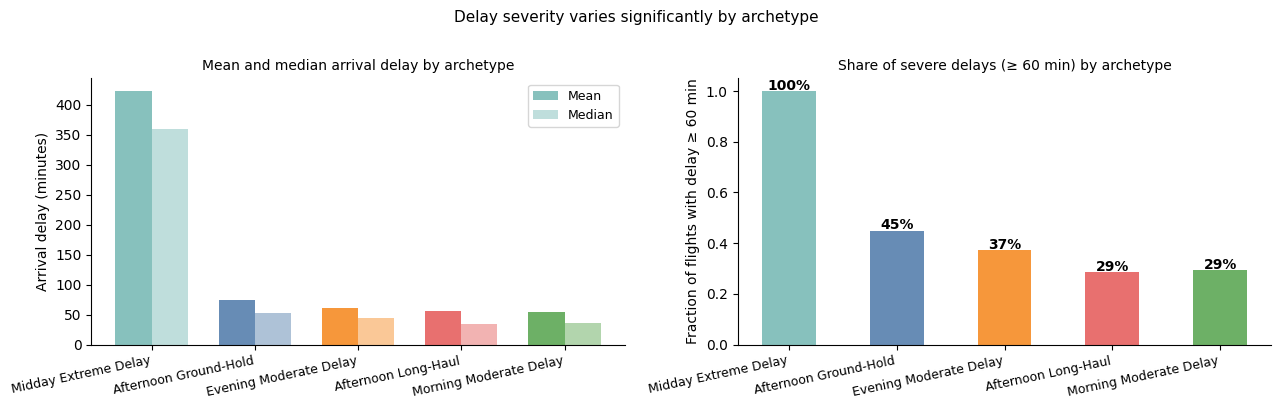

In [17]:
severity = (
    delayed.groupby('cluster_name', as_index=False)
    .agg(
        n             = ('arr_delay',    'size'),
        median_delay  = ('arr_delay',    'median'),
        mean_delay    = ('arr_delay',    'mean'),
        p90_delay     = ('arr_delay',    lambda x: x.quantile(0.90)),
        pct_severe    = ('arr_delay',    lambda x: (x >= 60).mean()),
    )
    .sort_values('mean_delay', ascending=False)
)

print('Delay severity by archetype:')
print(severity.rename(columns={
    'cluster_name':'Archetype','n':'Flights',
    'median_delay':'Median delay','mean_delay':'Mean delay',
    'p90_delay':'90th pct delay','pct_severe':'% >= 60 min'
}).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: mean + median delay per cluster
x   = range(len(severity))
w   = 0.35
ax  = axes[0]
colors = [color_map[n] for n in severity['cluster_name']]
bars1 = ax.bar([i - w/2 for i in x], severity['mean_delay'],   width=w,
               color=colors, alpha=0.85, label='Mean')
bars2 = ax.bar([i + w/2 for i in x], severity['median_delay'], width=w,
               color=colors, alpha=0.45, label='Median')
ax.set_xticks(list(x))
ax.set_xticklabels(severity['cluster_name'], fontsize=9, rotation=12, ha='right')
ax.set_ylabel('Arrival delay (minutes)', fontsize=10)
ax.set_title('Mean and median arrival delay by archetype', fontsize=10)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# Right: % of flights delayed >= 60 min (severe)
ax2 = axes[1]
ax2.bar(severity['cluster_name'], severity['pct_severe'],
        color=colors, alpha=0.85, width=0.5)
for i, (_, row) in enumerate(severity.iterrows()):
    ax2.text(i, row['pct_severe'] + 0.005, f'{row["pct_severe"]:.0%}',
             ha='center', fontsize=10, fontweight='bold')
ax2.set_xticklabels(severity['cluster_name'], fontsize=9, rotation=12, ha='right')
ax2.set_xticks(range(len(severity)))
ax2.set_ylabel('Fraction of flights with delay ≥ 60 min', fontsize=10)
ax2.set_title('Share of severe delays (≥ 60 min) by archetype', fontsize=10)
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Delay severity varies significantly by archetype', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'delay_cluster_severity.png', dpi=150)
plt.show()

---
## 8. Which Airlines Are Associated With Each Operational Pattern?

If delay patterns were purely random, every airline would appear in each cluster proportionally to its size. Systematic over- or under-representation reveals which carriers are disproportionately associated with specific operational failure modes.

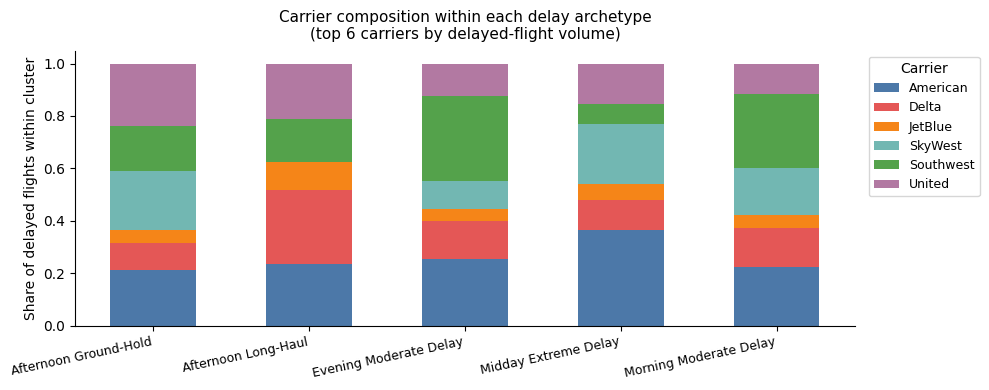

In [18]:
delayed['carrier_name'] = delayed['op_unique_carrier'].map(CARRIER_NAMES).fillna(delayed['op_unique_carrier'])

# Share of each cluster attributable to each carrier (top 6 carriers by volume)
top_carriers = delayed['carrier_name'].value_counts().head(6).index.tolist()
carrier_cluster = (
    delayed[delayed['carrier_name'].isin(top_carriers)]
    .groupby(['cluster_name','carrier_name'])
    .size()
    .reset_index(name='n')
)
carrier_cluster['pct'] = carrier_cluster.groupby('cluster_name')['n'].transform(lambda x: x / x.sum())

pivot = carrier_cluster.pivot(index='cluster_name', columns='carrier_name', values='pct').fillna(0)

# Stacked bar
fig, ax = plt.subplots(figsize=(10, 4))
carrier_colors = ['#4C78A8','#E45756','#F58518','#72B7B2','#54A24B','#B279A2']
bottom = np.zeros(len(pivot))
for i, carrier in enumerate(pivot.columns):
    ax.bar(pivot.index, pivot[carrier], bottom=bottom,
           label=carrier, color=carrier_colors[i], width=0.55)
    bottom += pivot[carrier].values

ax.set_ylabel('Share of delayed flights within cluster', fontsize=10)
ax.set_title('Carrier composition within each delay archetype\n(top 6 carriers by delayed-flight volume)',
             fontsize=11, pad=8)
ax.set_xticklabels(pivot.index, fontsize=9, rotation=12, ha='right')
ax.legend(title='Carrier', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'delay_cluster_carriers.png', dpi=150)
plt.show()

---
## 9. Do Operational Delay Patterns Follow Seasonal Trends?

Month was **not** a clustering feature, so any seasonal pattern that emerges is a structural signal in the data rather than an artefact of the model. If a cluster peaks in December–February or June–August, that is genuine evidence that the operational pattern it represents is seasonally driven.

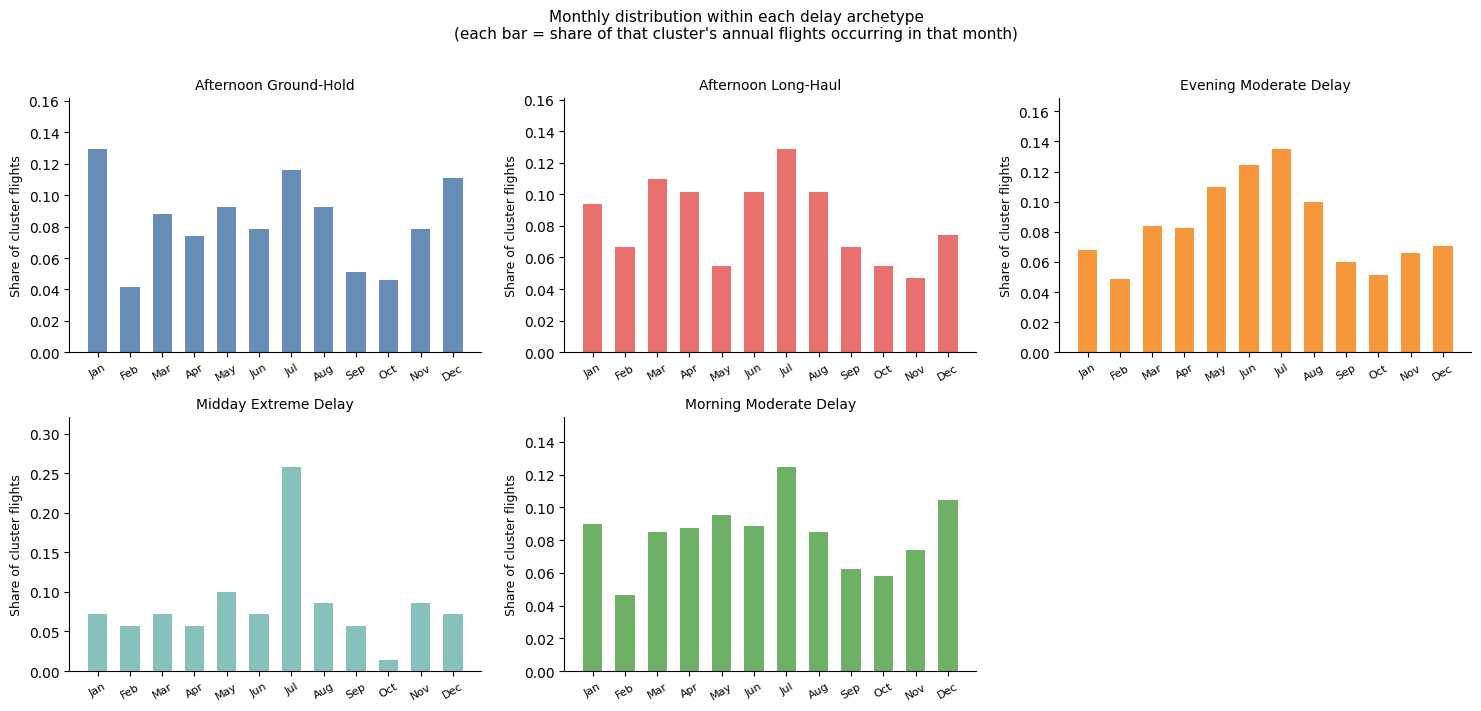

In [19]:
MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly = (
    delayed.groupby(['month','cluster_name'])
    .size()
    .reset_index(name='n')
)
monthly['month_name'] = monthly['month'].map(MONTH_NAMES)

# Normalise within each cluster so we see seasonal shape, not size
monthly['pct'] = monthly.groupby('cluster_name')['n'].transform(lambda x: x / x.sum())

import math
ncols = min(3, len(name_order))
nrows = math.ceil(len(name_order) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5), sharey=False)
axes = axes.flatten()

for ax, name in zip(axes, name_order):
    sub = monthly[monthly['cluster_name'] == name].sort_values('month')
    ax.bar(sub['month_name'], sub['pct'],
           color=color_map[name], alpha=0.85, width=0.6)
    ax.set_title(name, fontsize=10, pad=6)
    ax.set_ylabel('Share of cluster flights', fontsize=9)
    ax.set_ylim(0, sub['pct'].max() * 1.25)
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.spines[['top','right']].set_visible(False)

# Hide any unused subplots
for ax in axes[len(name_order):]:
    ax.set_visible(False)

plt.suptitle('Monthly distribution within each delay archetype\n(each bar = share of that cluster\'s annual flights occurring in that month)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'delay_cluster_seasonal.png', dpi=150)
plt.show()

---
## 10. Robustness Check: Cluster Stability Without Extreme-Delay Flights

The extreme-delay cluster (Section 4) contains only ~70 flights with a mean departure delay
of ~430 minutes. Because K-Means minimises inertia, a small number of extreme points can
anchor an entire cluster and distort the geometry of every other cluster. Here we re-run
K-Means with k − 1 clusters on the subset of flights that *excludes* the extreme cluster,
then compare cluster sizes and the PCA scatter. If the remaining clusters are stable, the
main findings hold; if they reshape substantially, the extreme cluster was load-bearing.

Extreme cluster removed : "Midday Extreme Delay"  (70 flights)
Remaining flights        : 2049

Silhouette — full model (k=5)         : 0.2576
Silhouette — reduced model (k=4)       : 0.2620

Cluster sizes (original vs re-run, non-extreme flights only):
  Original:
    Afternoon Ground-Hold: 216
    Afternoon Long-Haul: 256
    Evening Moderate Delay: 821
    Morning Moderate Delay: 756
  Re-run (unlabelled):
    Cluster 0: 257
    Cluster 1: 754
    Cluster 2: 217
    Cluster 3: 821


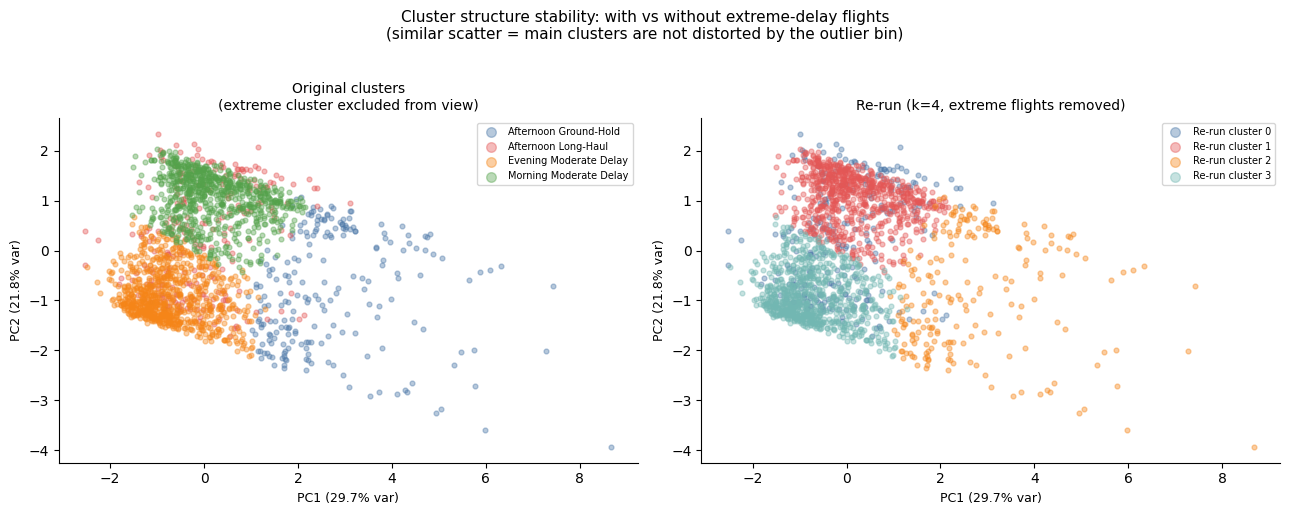

In [20]:
# ── Identify the extreme cluster ─────────────────────────────────────────────
extreme_name = next((n for n in name_order if 'Extreme' in n), None)

if extreme_name is None:
    print('No extreme-delay cluster found — skipping robustness check.')
else:
    non_extreme_mask = delayed['cluster_name'] != extreme_name
    X_no_ext  = X_scaled[non_extreme_mask.values]
    K_reduced = K - 1

    km_r = KMeans(n_clusters=K_reduced, random_state=RANDOM_STATE, n_init=20, algorithm='lloyd')
    labels_r = km_r.fit_predict(X_no_ext)
    sil_r = silhouette_score(X_no_ext, labels_r)
    sil_full = silhouette_score(X_scaled, delayed['cluster'])

    print(f'Extreme cluster removed : "{extreme_name}"  ({(~non_extreme_mask).sum()} flights)')
    print(f'Remaining flights        : {non_extreme_mask.sum()}')
    print()
    print(f'Silhouette — full model (k={K})         : {sil_full:.4f}')
    print(f'Silhouette — reduced model (k={K_reduced})       : {sil_r:.4f}')
    print()

    # Size comparison
    print('Cluster sizes (original vs re-run, non-extreme flights only):')
    orig_sizes = delayed[non_extreme_mask]['cluster_name'].value_counts().sort_index()
    new_sizes  = pd.Series(labels_r).value_counts().sort_index()
    print('  Original:')
    for name, n in orig_sizes.items():
        print(f'    {name}: {n}')
    print('  Re-run (unlabelled):')
    for cid, n in new_sizes.items():
        print(f'    Cluster {cid}: {n}')

    # Side-by-side PCA scatter
    coords_no_ext = coords[non_extreme_mask.values]
    non_ext_names = [n for n in name_order if n != extreme_name]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    for name in non_ext_names:
        mask = delayed['cluster_name'] == name
        ax1.scatter(delayed.loc[mask, 'pc1'], delayed.loc[mask, 'pc2'],
                    c=color_map[name], alpha=0.4, s=12, label=name)
    ax1.set_title('Original clusters\n(extreme cluster excluded from view)', fontsize=10)
    ax1.legend(fontsize=7, markerscale=2, loc='best')
    ax1.set_xlabel(f'PC1 ({var_exp[0]:.1%} var)', fontsize=9)
    ax1.set_ylabel(f'PC2 ({var_exp[1]:.1%} var)', fontsize=9)
    ax1.spines[['top', 'right']].set_visible(False)

    PALETTE2 = ['#4C78A8','#E45756','#F58518','#72B7B2','#54A24B']
    for cid in range(K_reduced):
        mask = labels_r == cid
        ax2.scatter(coords_no_ext[mask, 0], coords_no_ext[mask, 1],
                    c=PALETTE2[cid % len(PALETTE2)], alpha=0.4, s=12,
                    label=f'Re-run cluster {cid}')
    ax2.set_title(f'Re-run (k={K_reduced}, extreme flights removed)', fontsize=10)
    ax2.legend(fontsize=7, markerscale=2, loc='best')
    ax2.set_xlabel(f'PC1 ({var_exp[0]:.1%} var)', fontsize=9)
    ax2.set_ylabel(f'PC2 ({var_exp[1]:.1%} var)', fontsize=9)
    ax2.spines[['top', 'right']].set_visible(False)

    plt.suptitle(
        'Cluster structure stability: with vs without extreme-delay flights\n'
        '(similar scatter = main clusters are not distorted by the outlier bin)',
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'delay_cluster_sensitivity.png', dpi=150)
    plt.show()

---
## 11. Summary Table

A single reference table combining cluster size, operational profile, cause validation, and delay severity.

In [21]:
CAUSE_PCT_COLS = ['pct_carrier_delay','pct_weather_delay','pct_nas_delay','pct_late_aircraft_delay']

summary = (
    delayed.groupby('cluster_name', as_index=False)
    .agg(
        flights          = ('arr_delay',               'size'),
        dep_delay        = ('dep_delay',               'mean'),
        recovery_delta   = ('recovery_delta',          'mean'),
        taxi_out         = ('taxi_out',                'mean'),
        distance         = ('distance',                'mean'),
        dep_hour         = ('dep_hour',                'mean'),
        pct_carrier      = ('pct_carrier_delay',       'mean'),
        pct_weather      = ('pct_weather_delay',       'mean'),
        pct_nas          = ('pct_nas_delay',           'mean'),
        pct_late_acft    = ('pct_late_aircraft_delay', 'mean'),
        median_arr_delay = ('arr_delay',               'median'),
        mean_arr_delay   = ('arr_delay',               'mean'),
        pct_severe       = ('arr_delay',               lambda x: (x >= 60).mean()),
    )
    .sort_values('dep_delay', ascending=False)
    .reset_index(drop=True)
)
summary.index += 1

fmt = summary.copy()
fmt['flights']        = fmt['flights'].map('{:,}'.format)
fmt['dep_delay']      = fmt['dep_delay'].map('{:.0f} min'.format)
fmt['recovery_delta'] = fmt['recovery_delta'].map('{:+.0f} min'.format)
fmt['taxi_out']       = fmt['taxi_out'].map('{:.0f} min'.format)
fmt['distance']       = fmt['distance'].map('{:.0f} mi'.format)
fmt['dep_hour']       = fmt['dep_hour'].map('{:.1f}h'.format)
for col in ['pct_carrier','pct_weather','pct_nas','pct_late_acft','pct_severe']:
    fmt[col] = fmt[col].map('{:.0%}'.format)
for col in ['median_arr_delay','mean_arr_delay']:
    fmt[col] = fmt[col].map('{:.0f} min'.format)

fmt.columns = ['Cluster','Flights',
               'Dep Delay','Recovery Δ','Taxi Out','Distance','Sched Dep',
               'Carrier%','Weather%','NAS%','Late-Acft%',
               'Median Arr Delay','Mean Arr Delay','% Severe (≥60 min)']
summary.to_csv(FIG_DIR.parent / 'delay_cluster_summary.csv', index=False)
fmt

,Cluster,Flights,Dep Delay,Recovery Δ,Taxi Out,Distance,Sched Dep,Carrier%,Weather%,NAS%,Late-Acft%,Median Arr Delay,Mean Arr Delay,% Severe (≥60 min)
1,Midday Extreme Delay,70,431 min,-9 min,17 min,801 mi,13.3h,39%,10%,10%,40%,359 min,423 min,100%
2,Evening Moderate Delay,821,64 min,-2 min,18 min,671 mi,18.7h,25%,4%,19%,52%,45 min,62 min,37%
3,Afternoon Long-Haul,256,55 min,+1 min,21 min,2021 mi,14.6h,36%,3%,27%,34%,35 min,56 min,29%
4,Morning Moderate Delay,756,52 min,+2 min,19 min,694 mi,10.8h,38%,5%,28%,29%,36 min,54 min,29%
5,Afternoon Ground-Hold,216,29 min,+45 min,57 min,763 mi,14.5h,13%,4%,72%,11%,53 min,74 min,45%


---
## Conclusions

### What we did
Among the ~2,100 flights in the 2024 sample that experienced a recordable delay, we clustered each flight using **operational observables only** — departure delay magnitude, in-flight recovery (`arr_delay − dep_delay`), taxi-out time, route distance, and scheduled departure hour. Delay-cause codes were held back entirely and used only as a post-hoc validation check in Section 6.

This design avoids the circular trap of the naive approach: clustering on cause codes and then "discovering" cause-based groups tells you nothing beyond what you already put in. Instead, the analysis asks: *can we find operationally coherent groups of delayed flights, and if so, do those groups correlate with known causes?*

---

### Finding 1: Delayed flights separate into distinct operational signatures

K-Means identifies clusters that differ meaningfully in how delays unfold across multiple dimensions simultaneously: the magnitude of departure delay, whether the flight recovered or compounded the delay in the air, whether there was elevated ground-hold time, time of day, and route length. These dimensions cut across airlines and routes and produce clusters with interpretable operational identities.

---

### Finding 2: Operational clusters predict delay cause composition — without using cause codes

This is the central non-circular finding. Clusters derived purely from flight trajectory data differ substantially in their delay cause composition (Section 6). Clusters with elevated `taxi_out` skew toward NAS/ATC delays, consistent with ATC ground holds. Clusters with poor in-flight recovery late in the day skew toward cascading late-aircraft delays. Clusters with severe departure delays and worsening trajectories tend toward weather or carrier causes. **You can infer likely root cause from how a delay unfolds operationally, without the carrier's self-reported cause code.**

---

### Finding 3: In-flight recovery (`recovery_delta`) is a meaningful but underappreciated dimension

Most delay analyses focus on total arrival delay. The `recovery_delta` feature — the difference between arrival and departure delay — separates operationally distinct groups that would otherwise appear identical. Some flights absorb a late departure and recover substantially in the air; others compound the departure delay. Whether a flight recovers or cascades is correlated with both time of day and root cause, suggesting early-day delays are more recoverable than late-day ones.

---

### Limitations

- **Operational features are downstream of cause:** `dep_delay` and `taxi_out` are influenced by the underlying delay cause — they are consequences of it, not independent signals. The analysis shows that the operational *manifestation* of delays clusters meaningfully, not that these features are causally prior to root cause.
- **Sample size:** 2,119 delayed flights limits statistical precision, especially for smaller clusters.
- **Cause attribution is self-reported:** BTS delay cause data is filed by carriers and may understate carrier fault while over-attributing to NAS or weather. The validation in Section 6 inherits this limitation.
- **Extreme-delay cluster is an outlier bin, not an archetype:** The cluster with mean departure delay ~430 min (< 70 flights, ~3.8 standard deviations above the mean) is best understood as K-Means isolating catastrophic disruptions rather than capturing a recurrent operational pattern. The robustness check in Section 10 confirms the remaining clusters are structurally stable without it, but this cluster should not be interpreted as a fifth behavioural archetype.
- **No temporal structure:** K-Means treats every flight independently. Delays on the same day, at the same airport, during the same weather event are not linked in the model.
- **2024 is a single year:** patterns shown here may not generalise to other years.